<a href="https://colab.research.google.com/github/karimiMahnaz/Colab_Notebooks/blob/main/Bigdataset_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install wget

In [ ]:
!pip install kaggle

In [5]:
import os

# Create a directory for the Kaggle configuration
#!mkdir ~/.kaggle

# Copy the uploaded kaggle.json to the Kaggle directory
# Make sure you have uploaded kaggle.json to your Colab environment first
#!cp kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

Now you can download the dataset. You can find the dataset's API command on the Kaggle dataset page under the "API" section. For "Intel Image Classification", the command is `kaggle datasets download -d puneet6060/intel-image-classification`.

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

After downloading, the dataset will be in a zip file. You'll likely need to unzip it to access the image files.

In [ ]:
import zipfile
import os

# Specify the name of the downloaded zip file
zip_file_name = 'intel-image-classification.zip' # Replace with the actual zip file name if different

# Specify the directory to extract the contents
extract_dir = 'intel-image-classification'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset extracted to: {extract_dir}")

In [10]:
train_path = "/content/intel-image-classification/seg_train/seg_train"
test_path = "/content/intel-image-classification/seg_test/seg_test"
pred_path = "/content/intel-image-classification/seg_pred/seg_pred"

In [11]:
import os

In [ ]:
train_class_name = os.listdir(train_path)
train_class_name

In [6]:
test_class_name = os.listdir(test_path)

In [7]:
sub_train_path = os.listdir(f'{train_path}/{train_class_name[0]}')
len(sub_train_path)

2512

In [ ]:
class_count_train = {}
print(train_class_name)
for c in train_class_name:
  print(c)
  print(os.listdir(f'{train_path}/{c}'))
  print(len(os.listdir(f'{train_path}/{c}')))
  class_count_train[c] = len(os.listdir(f'{train_path}/{c}'))

class_count_train

In [9]:
class_name = list(class_count_train.keys())
class_name

['mountain', 'glacier', 'sea', 'buildings', 'street', 'forest']

In [10]:
class_count_train.values()

dict_values([2512, 2404, 2274, 2191, 2382, 2271])

In [11]:
import matplotlib.pyplot as plt

<BarContainer object of 6 artists>

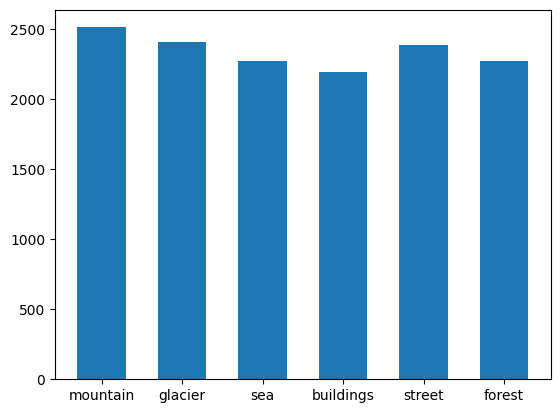

In [12]:
plt.bar(class_count_train.keys(), class_count_train.values(), width=.6)

In [9]:
# big dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_gen = ImageDataGenerator(rescale=1./255)


train_data_gen = data_gen.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode='categorical' )
test_data_gen = data_gen.flow_from_directory(test_path , target_size=(224,224), batch_size=32, class_mode='categorical')



NameError: name 'train_path' is not defined

In [14]:
train_batch = next(train_data_gen)
train_batch[0].shape

(32, 224, 224, 3)

In [15]:
train_batch[0][0].max() , train_batch[0][0].min()

(np.float32(1.0), np.float32(0.0))

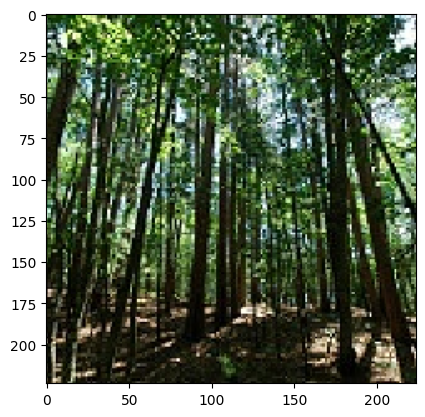

In [16]:
plt.imshow(train_batch[0][0])

In [17]:
train_batch[1].shape

(32, 6)

In [18]:
class_name[train_batch[1][1].argmax()]

'street'

In [19]:
class_name[train_batch[1][2].argmax()]


'buildings'

In [2]:
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow as tf

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
data_gen0 =ImageDataGenerator(width_shift_range=.1,
                             height_shift_range=.1,
                             horizontal_flip=True,
                             fill_mode ='nearest')

In [6]:
reg = keras.regularizers.l2(.003)

In [7]:
batch_size = 10

In [ ]:
train_data_gen = data_gen0.flow(train_data_gen, batch_size=batch_size)

In [ ]:
# model architecture

model = keras.models.Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu',
                 kernel_regularizer=reg, input_shape=(32,32,3), name= 'Conv1'))
model.add(Dropout(.25, name = 'drop1'))
model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv2'))
model.add(Dropout(.25, name = 'drop2'))
model.add(MaxPool2D(name='pool1'))
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv3'))
model.add(Dropout(.25, name = 'drop3'))
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv4'))
model.add(Dropout(.25, name = 'drop4'))
model.add(MaxPool2D(name='pool2'))
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv5'))
model.add(Dropout(.25, name = 'drop5'))
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv6'))
model.add(Dropout(.25, name = 'drop6'))
model.add(Flatten(name='flatten'))
model.add(Dense(units=512, activation='relu', kernel_regularizer=reg, name ='hidden1'))
model.add(Dropout(.5, name = 'drop7'))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=reg, name ='output'))

In [ ]:
# complile model
opt = tf.optimizers.Adam(learning_rate=.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model.compile(optimizer=opt, loss=loss, metrics=[metric])

In [ ]:
model.fit(train_data_gen, epochs=10, batch_size=batch_size, validation_data=(x_val, y_val), verbose=2)

In [ ]:
model.evaluate(x_test, y_test)